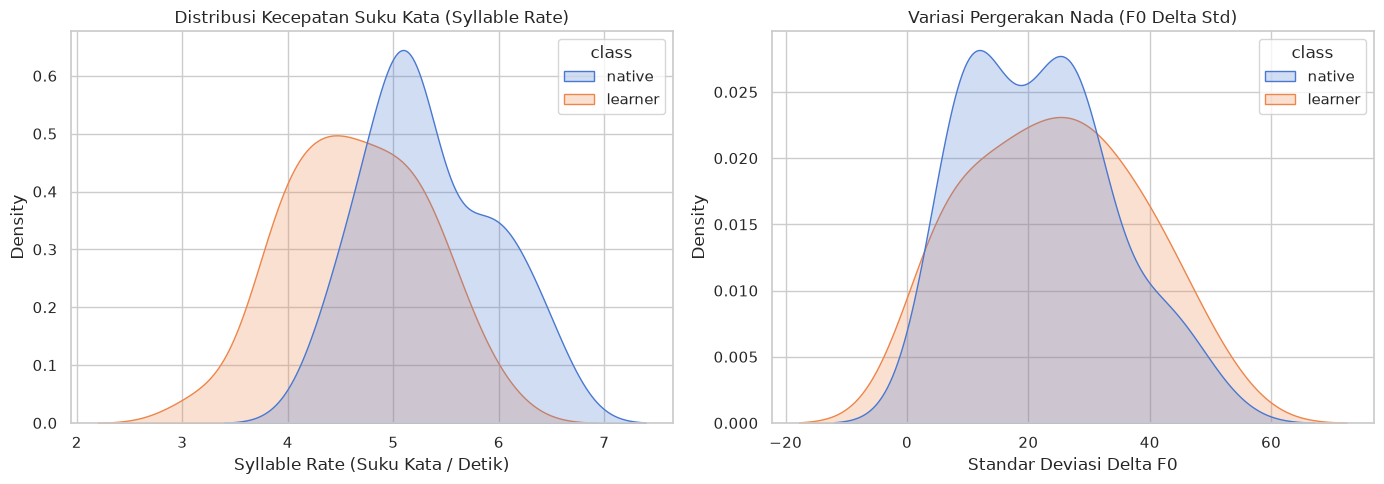

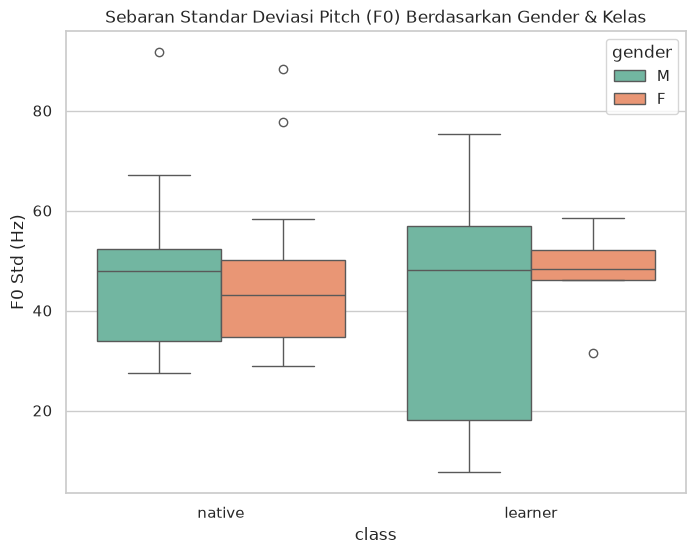

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Konfigurasi gaya visual
sns.set_theme(style="whitegrid", palette="muted")

# 1. Load fitur dan metadata
df = pd.read_csv('features.csv')
df_meta = pd.read_csv('metadata_utterance.csv')[['speaker_id', 'gender', 'location']].drop_duplicates('speaker_id')

# 2. Gabungkan kembali kolom gender dan location berdasarkan speaker_id
df = df.merge(df_meta, on='speaker_id', how='left')

# Pastikan kolom tidak memiliki nilai NaN sebelum di-plot
df_clean = df.dropna(subset=['syllable_rate', 'f0_delta_std', 'f0_std'])

# 3. Distribusi Kepadatan (KDE) Fitur Prosodi Utama
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(data=df_clean, x='syllable_rate', hue='class', fill=True, common_norm=False, ax=axes[0])
axes[0].set_title('Distribusi Kecepatan Suku Kata (Syllable Rate)')
axes[0].set_xlabel('Syllable Rate (Suku Kata / Detik)')

sns.kdeplot(data=df_clean, x='f0_delta_std', hue='class', fill=True, common_norm=False, ax=axes[1])
axes[1].set_title('Variasi Pergerakan Nada (F0 Delta Std)')
axes[1].set_xlabel('Standar Deviasi Delta F0')

plt.tight_layout()
plt.savefig('distribusi_prosodi.png', dpi=300)
plt.show()

# 4. Boxplot Komparasi Lintas Kelompok
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_clean, x='class', y='f0_std', hue='gender', palette='Set2')
plt.title('Sebaran Standar Deviasi Pitch (F0) Berdasarkan Gender & Kelas')
plt.ylabel('F0 Std (Hz)')
plt.savefig('boxplot_f0_gender.png', dpi=300)
plt.show()